### Purpose
Establish whether short-horizon predictive signal exists at all and compare simple baselines before moving to richer models.


#### Project root setup

In [26]:
from pathlib import Path
import os
import sys

def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    current = start.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "config.yaml").exists() and (candidate / "data").exists():
            return candidate

    raise FileNotFoundError(
        "Could not find project root containing both 'config.yaml' and 'data' directory."
    )

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("cwd =", Path.cwd())

PROJECT_ROOT = /home/zakhar/PycharmProjects/PythonProject5
cwd = /home/zakhar/PycharmProjects/PythonProject5


#### Imports

In [27]:
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

from pathlib import Path

from src.baselines import (
    zero_baseline,
    microprice_gap_score,
    imbalance_score,
    fit_score_calibrator,
    apply_score_calibrator,
)
from src.metrics import evaluate_predictions

#### Load config

In [28]:
with open("config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

cfg["time"]["horizons_sec"]

[1, 5, 10]

#### Load target table

In [29]:
targets_df = pd.read_parquet(cfg["data"]["targets_path"])
print(targets_df.shape)
targets_df.head()

(987938, 22)


,row_id,timestamp,event_dt,file_date,session_type,session_id,split,future_dt_1s,future_mid_1s,valid_target_1s,...,future_dt_5s,future_mid_5s,valid_target_5s,delta_mid_5s,y_logret_5s,future_dt_10s,future_mid_10s,valid_target_10s,delta_mid_10s,y_logret_10s
0,0,1748941200153000000,2025-06-03 09:00:00.153000000,20250603,main,20250603_main,train,2025-06-03 09:00:01.447000000,10.9320,True,...,2025-06-03 09:00:05.433000000,10.934,True,0.0010,0.000091,2025-06-03 09:00:10.250,10.9415,True,0.0085,0.000777
1,1,1748941200390000000,2025-06-03 09:00:00.390000000,20250603,main,20250603_main,train,2025-06-03 09:00:01.447000000,10.9320,True,...,2025-06-03 09:00:05.433000000,10.934,True,0.0010,0.000091,2025-06-03 09:00:10.563,10.9415,True,0.0085,0.000777
2,2,1748941200767000000,2025-06-03 09:00:00.767000000,20250603,main,20250603_main,train,2025-06-03 09:00:01.787000002,10.9320,True,...,2025-06-03 09:00:05.990000002,10.934,True,0.0010,0.000091,2025-06-03 09:00:11.057,10.9415,True,0.0085,0.000777
3,3,1748941201003000002,2025-06-03 09:00:01.003000002,20250603,main,20250603_main,train,2025-06-03 09:00:02.403000000,10.9325,True,...,2025-06-03 09:00:06.030000000,10.934,True,0.0015,0.000137,2025-06-03 09:00:11.057,10.9415,True,0.0090,0.000823
4,4,1748941201053000000,2025-06-03 09:00:01.053000000,20250603,main,20250603_main,train,2025-06-03 09:00:02.403000000,10.9325,True,...,2025-06-03 09:00:06.057000000,10.934,True,0.0015,0.000137,2025-06-03 09:00:11.057,10.9415,True,0.0090,0.000823


#### Inspect `clean.parquet` schema and choose baseline features

In [30]:
pf = pq.ParquetFile(cfg["data"]["clean_path"])
all_cols = pf.schema.names

if "imbalance_l1" in all_cols:
    imbalance_col = "imbalance_l1"
elif "imbalance_depth_weighted" in all_cols:
    imbalance_col = "imbalance_depth_weighted"
else:
    raise ValueError("No imbalance feature found in clean dataset.")

required_feature_cols = [
    "timestamp",
    "mid_price",
    "microprice",
    "spread",
    imbalance_col,
]

missing_cols = [c for c in required_feature_cols if c not in all_cols]
if missing_cols:
    raise ValueError(f"Missing baseline feature columns: {missing_cols}")

required_feature_cols

['timestamp', 'mid_price', 'microprice', 'spread', 'imbalance_l1']

#### Load minimal feature subset and align it with targets

In [31]:
features_df = pd.read_parquet(
    cfg["data"]["clean_path"],
    columns=required_feature_cols,
)

assert len(features_df) == len(targets_df), "features and targets lengths differ"
assert np.array_equal(
    features_df["timestamp"].to_numpy(),
    targets_df["timestamp"].to_numpy()
), "timestamp alignment mismatch"

df = features_df.copy()

cols_to_attach = [c for c in targets_df.columns if c not in df.columns]
for c in cols_to_attach:
    df[c] = targets_df[c].to_numpy()

df["split"].value_counts(dropna=False)

split
train     591998
test      197352
val       196165
purged      2423
Name: count, dtype: int64

#### Evaluate simple baselines across horizons

In [32]:
rows = []

for h in cfg["time"]["horizons_sec"]:
    target_col = f"y_logret_{h}s"
    valid_col = f"valid_target_{h}s"

    use_mask = df["split"].isin(["train", "val", "test"]) & df[valid_col].fillna(False)
    part = df.loc[
        use_mask,
        ["split", target_col, "mid_price", "microprice", "spread", imbalance_col]
    ].copy()

    train_mask = part["split"] == "train"
    y_train = part.loc[train_mask, target_col].to_numpy()

    # 1) Zero baseline
    part["pred_zero"] = zero_baseline(part)
    rows.append(
        evaluate_predictions(
            part,
            target_col=target_col,
            pred_col="pred_zero",
            model_name="zero",
            horizon_sec=h,
        )
    )

    # 2) Calibrated microprice baseline
    micro_score = microprice_gap_score(part)
    micro_calibrator = fit_score_calibrator(
        micro_score[train_mask.to_numpy()],
        y_train,
    )
    part["pred_microprice"] = apply_score_calibrator(micro_calibrator, micro_score)
    rows.append(
        evaluate_predictions(
            part,
            target_col=target_col,
            pred_col="pred_microprice",
            model_name="microprice_calibrated",
            horizon_sec=h,
        )
    )

    # 3) Calibrated imbalance baseline
    imb_score = imbalance_score(part)
    imb_calibrator = fit_score_calibrator(
        imb_score[train_mask.to_numpy()],
        y_train,
    )
    part["pred_imbalance"] = apply_score_calibrator(imb_calibrator, imb_score)
    rows.append(
        evaluate_predictions(
            part,
            target_col=target_col,
            pred_col="pred_imbalance",
            model_name="imbalance_calibrated",
            horizon_sec=h,
        )
    )

baseline_metrics = pd.concat(rows, ignore_index=True)
baseline_metrics = baseline_metrics.sort_values(
    ["horizon_sec", "split", "model"]
).reset_index(drop=True)

baseline_metrics

/home/zakhar/PycharmProjects/PythonProject5/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/zakhar/PycharmProjects/PythonProject5/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/zakhar/PycharmProjects/PythonProject5/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/zakhar/PycharmProjects/PythonProject5/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/zakhar/PycharmProjects/PythonProject5/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/zakhar/PycharmProjects/Python

,n_obs,rmse,mae,r2,pearson_ic,spearman_ic,model,horizon_sec,split
0,197350,0.000069,0.000040,1.212339e-02,0.155258,0.210693,imbalance_calibrated,1,test
1,197350,0.000070,0.000036,-9.453065e-03,0.006447,0.265295,microprice_calibrated,1,test
2,197350,0.000070,0.000036,-1.150056e-02,NaN,NaN,zero,1,test
3,591998,0.000074,0.000044,2.431170e-02,0.155922,0.204755,imbalance_calibrated,1,train
4,591998,0.000075,0.000040,1.103912e-06,0.001051,0.227886,microprice_calibrated,1,train
5,591998,0.000075,0.000040,-8.538213e-05,NaN,NaN,zero,1,train
6,196165,0.000058,0.000034,9.985833e-03,0.132712,0.191608,imbalance_calibrated,1,val
7,196165,0.000059,0.000030,-3.554800e-03,0.156487,0.232970,microprice_calibrated,1,val
8,196165,0.000059,0.000030,-5.103967e-03,NaN,NaN,zero,1,val
9,197327,0.000114,0.000069,1.589861e-02,0.142715,0.193111,imbalance_calibrated,5,test


#### Compare baseline quality on validation and test

In [33]:
baseline_metrics.query("split in ['val', 'test']").sort_values(
    ["split", "horizon_sec", "pearson_ic"],
    ascending=[True, True, False]
)

,n_obs,rmse,mae,r2,pearson_ic,spearman_ic,model,horizon_sec,split
0,197350,0.000069,0.000040,0.012123,0.155258,0.210693,imbalance_calibrated,1,test
1,197350,0.000070,0.000036,-0.009453,0.006447,0.265295,microprice_calibrated,1,test
2,197350,0.000070,0.000036,-0.011501,NaN,NaN,zero,1,test
9,197327,0.000114,0.000069,0.015899,0.142715,0.193111,imbalance_calibrated,5,test
10,197327,0.000115,0.000067,-0.003070,0.019148,-0.227006,microprice_calibrated,5,test
11,197327,0.000115,0.000066,-0.007492,NaN,NaN,zero,5,test
18,197315,0.000147,0.000087,0.011707,0.115363,0.167480,imbalance_calibrated,10,test
19,197315,0.000148,0.000085,-0.000759,0.004946,-0.194938,microprice_calibrated,10,test
20,197315,0.000148,0.000085,-0.001975,NaN,NaN,zero,10,test
7,196165,0.000059,0.000030,-0.003555,0.156487,0.232970,microprice_calibrated,1,val


In [34]:
pearson_summary = baseline_metrics.pivot_table(
    index=["horizon_sec", "model"],
    columns="split",
    values="pearson_ic",
)

pearson_summary

split                                  test     train       val
horizon_sec model                                              
1           imbalance_calibrated   0.155258  0.155922  0.132712
            microprice_calibrated  0.006447  0.001051  0.156487
5           imbalance_calibrated   0.142715  0.136887  0.052665
            microprice_calibrated  0.019148  0.000672 -0.066660
10          imbalance_calibrated   0.115363  0.111125  0.027553
            microprice_calibrated  0.004946  0.001370 -0.037317

In [35]:
best_h_row = (
    baseline_metrics
    .query("model == 'imbalance_calibrated' and split == 'val'")
    .sort_values("pearson_ic", ascending=False)
    .iloc[0]
)

best_h = int(best_h_row["horizon_sec"])
print("Best horizon selected from baseline stage:", best_h)
best_h_row.to_frame().T

Best horizon selected from baseline stage: 1


,n_obs,rmse,mae,r2,pearson_ic,spearman_ic,model,horizon_sec,split
6,196165,0.000058,0.000034,0.009986,0.132712,0.191608,imbalance_calibrated,1,val


#### Visualize test Pearson IC by horizon

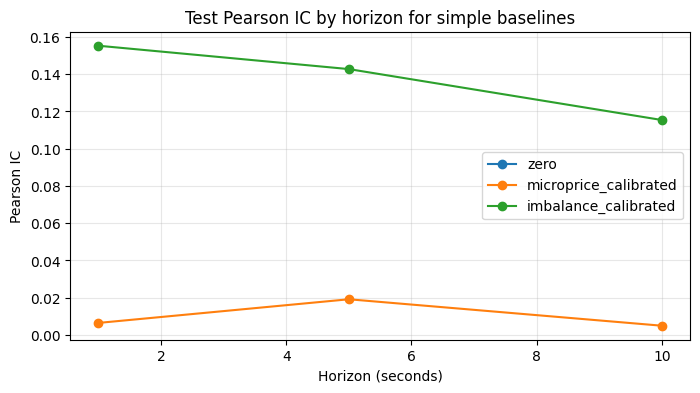

In [36]:
plot_df = baseline_metrics.query("split == 'test'").copy()

fig, ax = plt.subplots(figsize=(8, 4))

for model_name in ["zero", "microprice_calibrated", "imbalance_calibrated"]:
    part = plot_df[plot_df["model"] == model_name].sort_values("horizon_sec")
    ax.plot(part["horizon_sec"], part["pearson_ic"], marker="o", label=model_name)

ax.set_title("Test Pearson IC by horizon for simple baselines")
ax.set_xlabel("Horizon (seconds)")
ax.set_ylabel("Pearson IC")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

#### Save baseline results

In [37]:
tables_dir = Path("outputs/tables")
tables_dir.mkdir(parents=True, exist_ok=True)

baseline_metrics.to_csv(tables_dir / "baseline_metrics_light.csv", index=False)

print("Saved to:", (tables_dir / "baseline_metrics_light.csv").resolve())

Saved to: /home/zakhar/PycharmProjects/PythonProject5/outputs/tables/baseline_metrics_light.csv


## Short notebook conclusion

In the purged single-session setup, the strongest baseline performance is observed at the **1-second horizon**.

Among simple benchmarks, the **calibrated imbalance baseline** is the most robust on validation and test. The **microprice baseline** remains informative but is less stable out of sample. Because the target is strongly concentrated around zero, **information-coefficient metrics** are more informative than MAE alone.

The main takeaway from the baseline stage is that further supervised modeling should be judged by whether it can deliver robust lift over the imbalance baseline at the 1-second horizon.